# Seasonal Agriculture Performance Analysis

**Subject:** Data Analytics  
**Domain:** Agriculture  
**Tools Used:** Python, Pandas, NumPy, Matplotlib and Seaborn

### My project
In this project, I am trying to understand how agricultural performance changes with season, crop, weather conditions and farming practices.

I will first clean the data and then use different types of analysis to find useful patterns.

## 1. Problem Statement

Agricultural performance can change because of rainfall, temperature, soil conditions, irrigation, fertilizer use, crop type and season.

The aim of this project is to analyze the given farm-level dataset and find which seasons and farming conditions are associated with better yield, profit and water efficiency.

## 2. Objectives

The main objectives of my analysis are:

- Understand the dataset structure.
- Check missing values and duplicate records.
- Perform descriptive statistical analysis.
- Study individual variables using univariate analysis.
- Compare two variables using bivariate analysis.
- Study multiple variables together.
- Check correlations between numerical variables.
- Compare agricultural performance across seasons.
- Perform at least 3 additional analyses of my own.
- Write meaningful insights and recommendations from the results.

## 3. Import Libraries

I am using the following libraries for data cleaning, calculations and visualization.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

%matplotlib inline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 4. Load the Dataset

The original dataset is a CSV file. The first path is the one used in the original notebook. If it is not available, the upload option can be used in Google Colab.

In [5]:
import os

file_path = "/content/seasonal_agriculture_performance_dataset.csv"

if not os.path.exists(file_path):
    try:
        from google.colab import files
        print("CSV file was not found at the default path.")
        print("Please upload the dataset CSV.")
        uploaded = files.upload()
        file_path = "/content/" + list(uploaded.keys())[0]
    except Exception:
        raise FileNotFoundError(
            "Please upload the seasonal agriculture performance CSV file."
        )

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("File used:", os.path.basename(file_path))

Dataset loaded successfully.
File used: seasonal_agriculture_performance_dataset.csv


## 5. Initial Data Understanding

I first want to see the size and basic structure of the dataset.

In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [7]:
# Top 5 rows
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [8]:
# I also checked a few random records so that I am not only looking at the first rows.
df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [9]:
print("Column names:")
for col in df.columns:
    print("-", col)

Column names:
- Farm_ID
- State
- District
- Crop
- Season
- Farm_Area_Hectares
- Rainfall_mm
- Avg_Temperature_C
- Humidity_pct
- Sunlight_Hours_Day
- Soil_pH
- Soil_Moisture_pct
- Nitrogen_kg_ha
- Phosphorus_kg_ha
- Potassium_kg_ha
- Irrigation_Method
- Fertilizer_kg_ha
- Pesticide_Litre_ha
- Seed_Quality_Score
- Yield_Tonnes_Ha
- Production_Tonnes
- Market_Price_INR_Tonne
- Total_Cost_INR
- Revenue_INR
- Profit_INR
- Water_Used_m3
- Water_Efficiency_t_per_1000m3
- Disease_Pest_Risk_pct


In [10]:
print("Data types and non-null values:")
df.info()

Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha  

In [11]:
# Numerical summary
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [12]:
# Categorical summary
df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


## 6. Data Quality Check

Before doing the main analysis, I checked:

1. Missing values
2. Duplicate rows
3. Data types
4. Unusual values in numerical columns

In [13]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage.round(2)
})

missing_summary[missing_summary["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


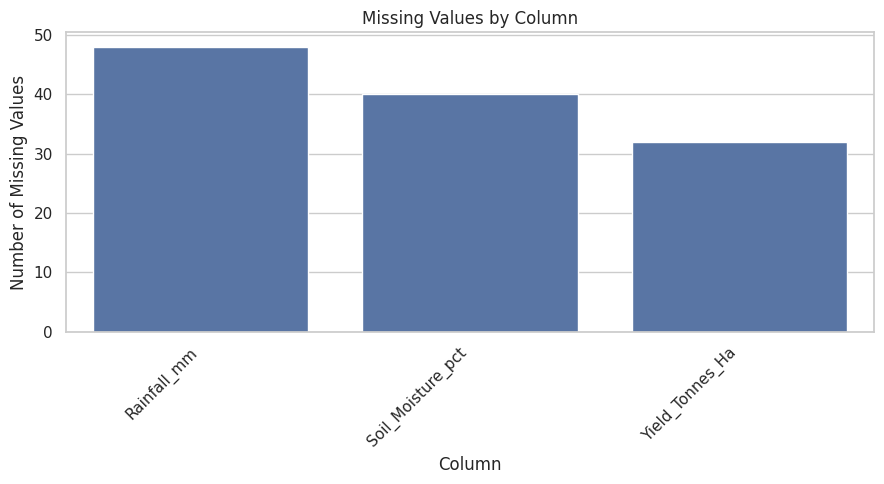

In [14]:
# Visual check of missing values
missing_plot = missing[missing > 0]

plt.figure(figsize=(9, 5))

if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot.values)
    plt.xticks(rotation=45, ha="right")
    plt.title("Missing Values by Column")
    plt.xlabel("Column")
    plt.ylabel("Number of Missing Values")
else:
    plt.text(0.5, 0.5, "No missing values found", ha="center", va="center")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [16]:
# Remove exact duplicate records if there are any.
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after duplicate removal:", df.shape)

Shape after duplicate removal: (4000, 28)


In [17]:
# Check categorical values
categorical_columns = df.select_dtypes(include="object").columns.tolist()

for col in categorical_columns:
    print(f"\n{col}")
    print("Number of unique values:", df[col].nunique())
    print(df[col].dropna().unique()[:20])


Farm_ID
Number of unique values: 4000
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State
Number of unique values: 8
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District
Number of unique values: 10
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop
Number of unique values: 8
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season
Number of unique values: 3
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method
Number of unique values: 4
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


### Missing Value Treatment

The missing values are in numerical columns. Since the number of missing records is small compared with the full dataset, I used median imputation.

I chose the median because it is less affected by extreme values than the mean.

In [18]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:", int(df.isnull().sum().sum()))

Remaining missing values: 0


## 7. Variable Review

I separated the variables into numerical and categorical columns to understand what type of analysis can be done.

In [19]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


## 8. Descriptive / Statistical Analysis

In [20]:
stats = df[numeric_columns].describe().T
stats["Range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]

stats.round(2)

,count,mean,std,min,25%,50%,75%,max,Range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.90,11.65,15.00,14.50,7.39
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20","1,315.20",460.40
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.78,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [21]:
statistical_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Std_Dev": df[numeric_columns].std(),
    "Min": df[numeric_columns].min(),
    "Max": df[numeric_columns].max()
})

statistical_summary.round(2)

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.90,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [22]:
# Seasonal descriptive statistics
season_summary = df.groupby("Season")[numeric_columns].agg(["mean", "median", "std"])
season_summary

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      849.20 853.10 183.69   
Rabi                 7.75   7.68 4.18      437.62 432.20 175.35   
Zaid                 8.09   8.09 4.16      304.65 288.20 157.24   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.15   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.07   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.28   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.10 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.94         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.94         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.19 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.63   1.94 14.39             46.31  13.24 135.70   
Rabi              5.04   1.67 12.75             41.49  11.08 121.90   
Zaid              4.64   1.46 11.27             38.89   9.97 112.00   

       Market_Price_INR_Tonne                     Total_Cost_INR             \
                         mean    median       std           mean     median   
Season                                                                        
Kharif              44,850.91 25,793.00 30,301.56     531,804.41 524,840.00   
Rabi                44,747.97 26,041.00 30,309.56     513,836.58 506,733.00   
Zaid                44,212.03 25,749.50 30,086.23     543,976.73 534,833.00   

                  Revenue_INR                       Profit_INR             \
              std        mean     median        std       mean     median   
Season                                                                      
Kharif 298,487.69  710,719.06 520,196.00 708,710.37 178,914.65  38,808.00   
Rabi   288,386.89  601,526.05 438,156.00 584,545.52  87,689.47  -3,187.00   
Zaid   297,576.86  519,171.90 373,700.50 509,524.55 -24,804.82 -62,144.00   

                  Water_Used_m3             

## 9. Univariate Analysis

Here I look at one variable at a time.

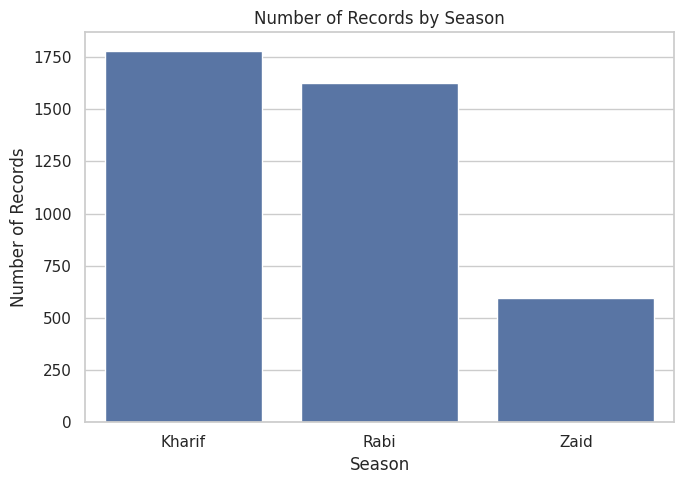

In [23]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Season")
plt.title("Number of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

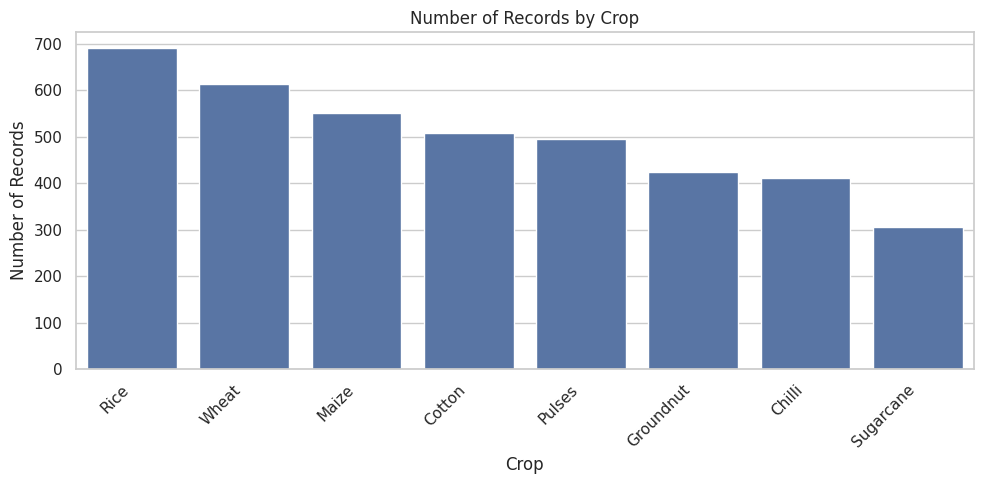

In [24]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index)
plt.xticks(rotation=45, ha="right")
plt.title("Number of Records by Crop")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

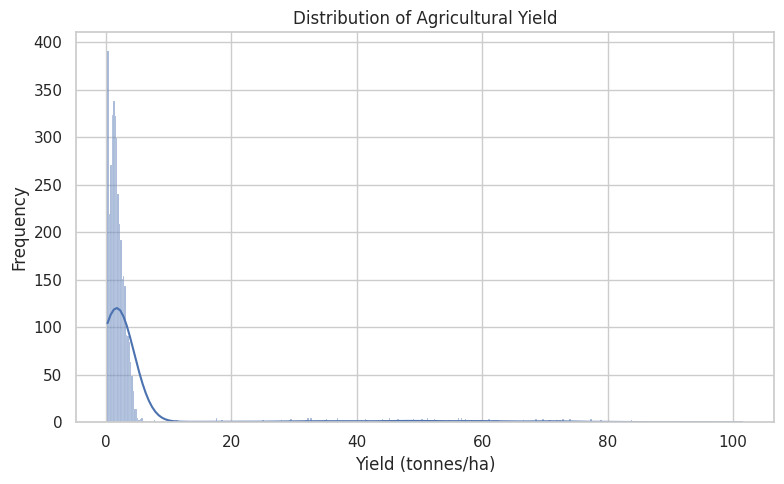

In [25]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Yield_Tonnes_Ha", kde=True)
plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

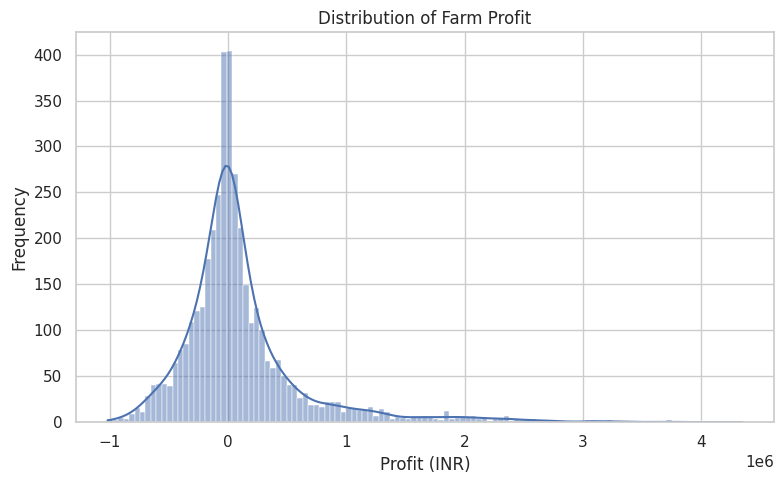

In [26]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Profit_INR", kde=True)
plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

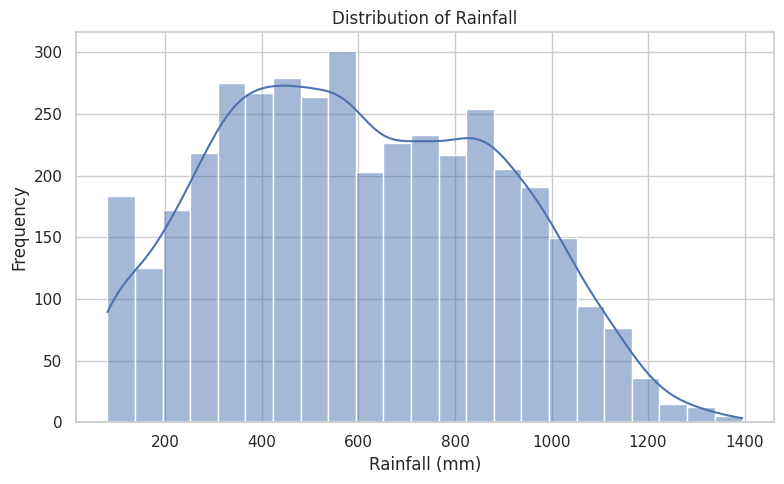

In [27]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Rainfall_mm", kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

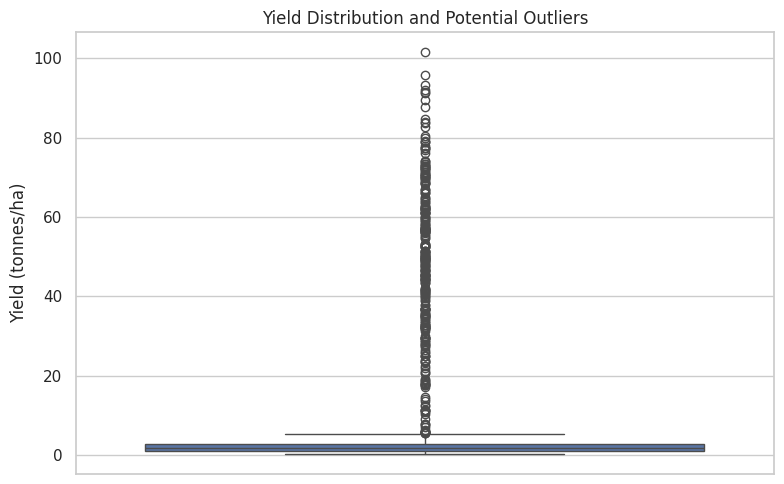

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y="Yield_Tonnes_Ha")
plt.title("Yield Distribution and Potential Outliers")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

## 10. Outlier Analysis

IQR was used to identify possible outliers. I am not automatically deleting them because an extreme agricultural value can sometimes represent a real farm or crop result.

For example, the dataset contains crops such as sugarcane with much higher yield than many other crops, so removing every extreme value could hide an important pattern.

In [29]:
outlier_summary = []

for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": count,
        "Outlier_Percentage": round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    "Outlier_Count", ascending=False
)

outlier_summary

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,"-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


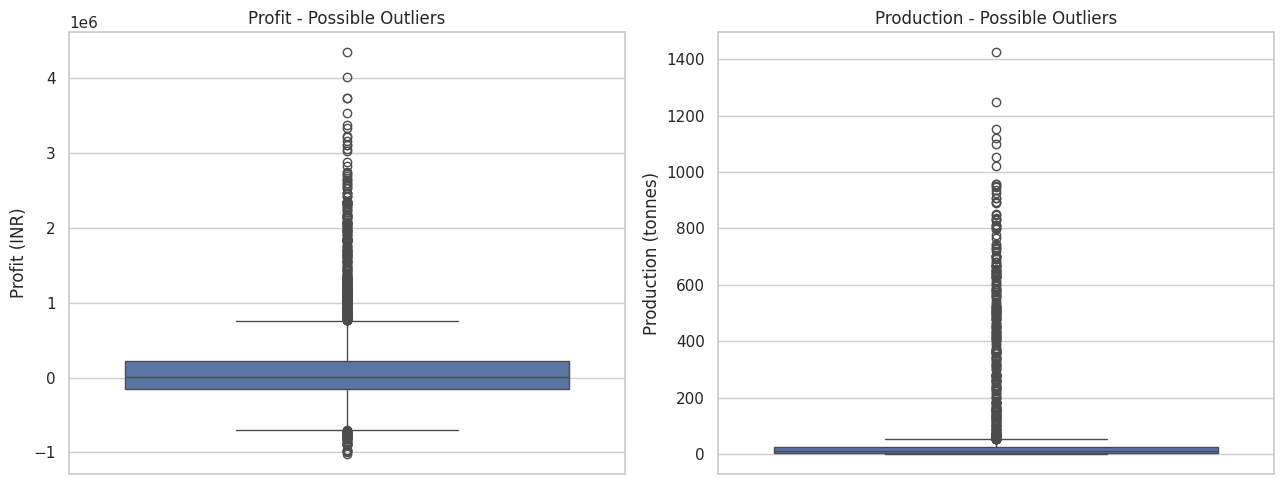

In [30]:
# A second visual look at the two main performance measures
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, y="Profit_INR", ax=axes[0])
axes[0].set_title("Profit - Possible Outliers")
axes[0].set_ylabel("Profit (INR)")

sns.boxplot(data=df, y="Production_Tonnes", ax=axes[1])
axes[1].set_title("Production - Possible Outliers")
axes[1].set_ylabel("Production (tonnes)")

plt.tight_layout()
plt.show()

## 11. Bivariate Analysis

Now I compare two variables at a time to understand relationships and differences.

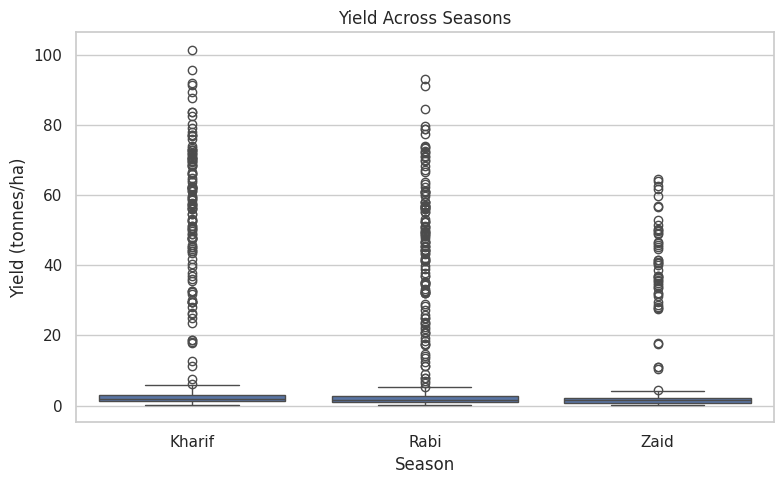

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

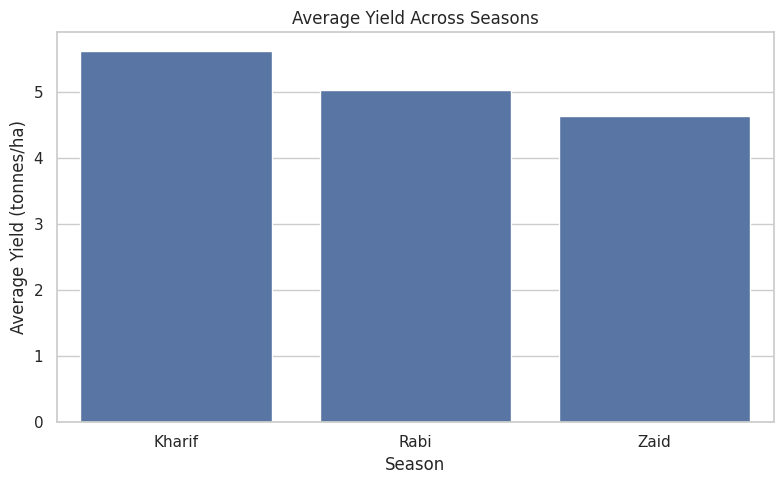

In [32]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Yield_Tonnes_Ha", errorbar=None)
plt.title("Average Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

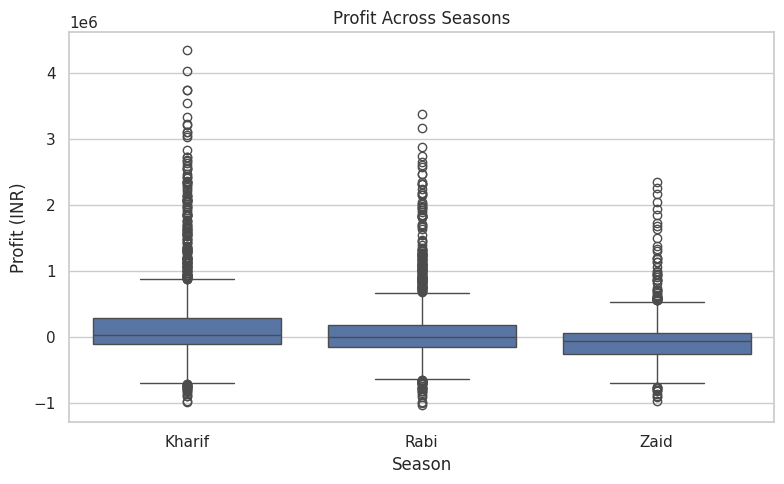

In [33]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Profit_INR")
plt.title("Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

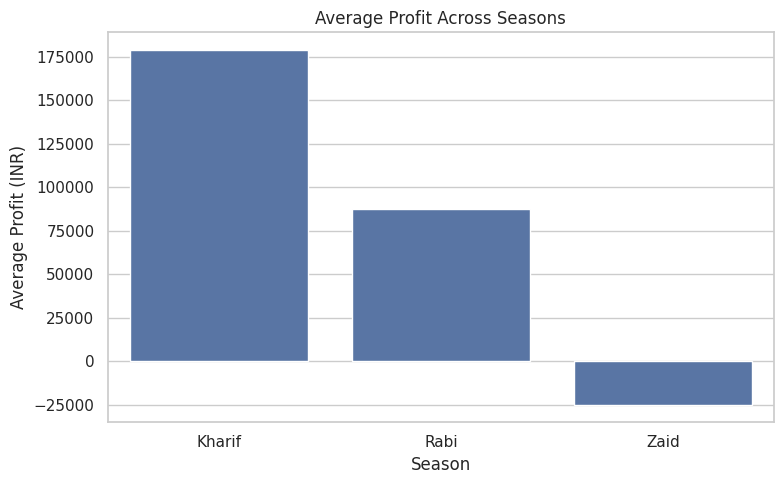

In [34]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Profit_INR", errorbar=None)
plt.title("Average Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

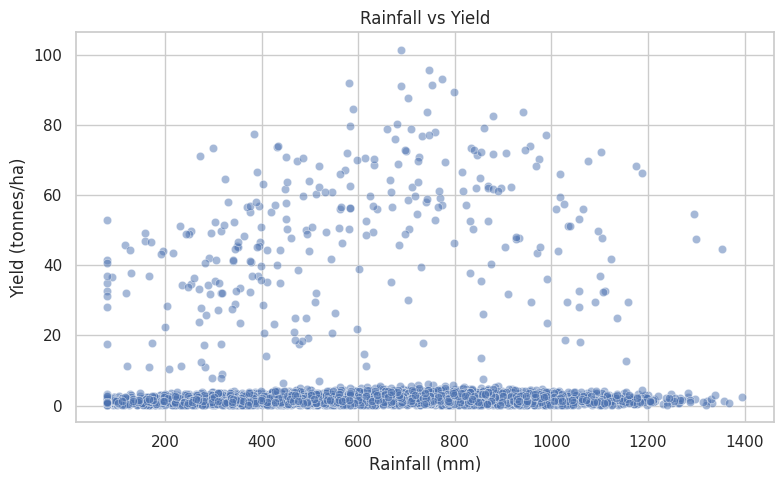

In [35]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", alpha=0.5)
plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

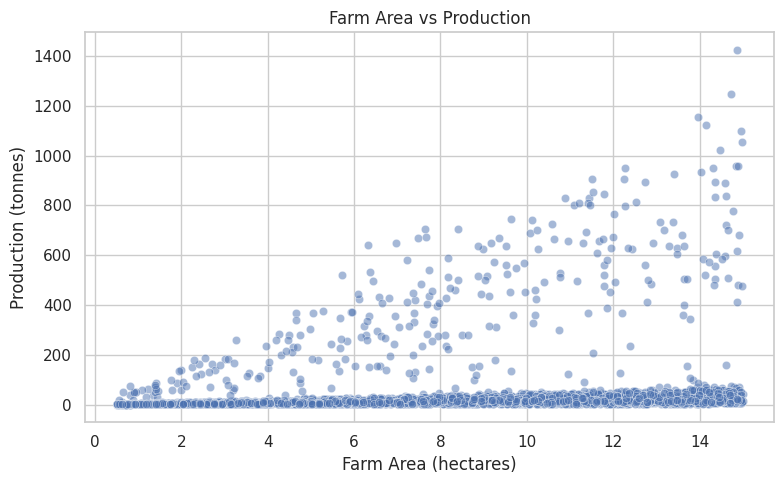

In [36]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Farm_Area_Hectares", y="Production_Tonnes", alpha=0.5)
plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (hectares)")
plt.ylabel("Production (tonnes)")
plt.tight_layout()
plt.show()

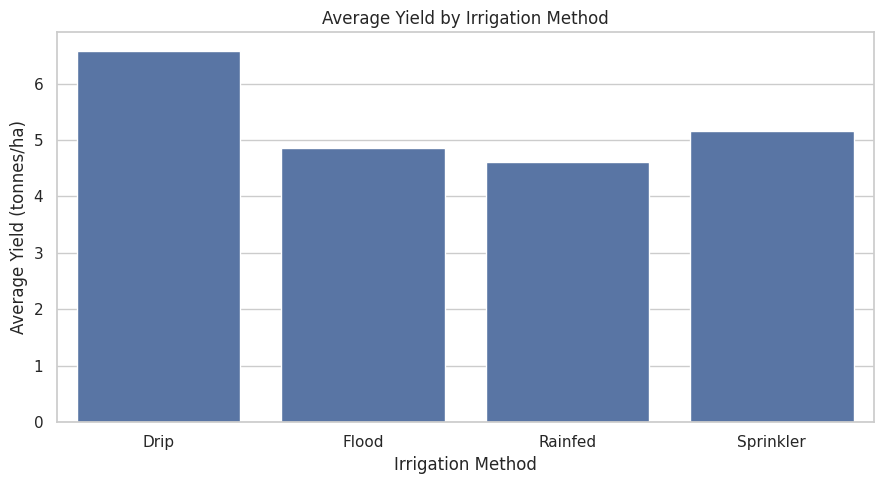

In [37]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", errorbar=None)
plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

## 12. Multivariate Analysis

In this section I look at more than two variables together.

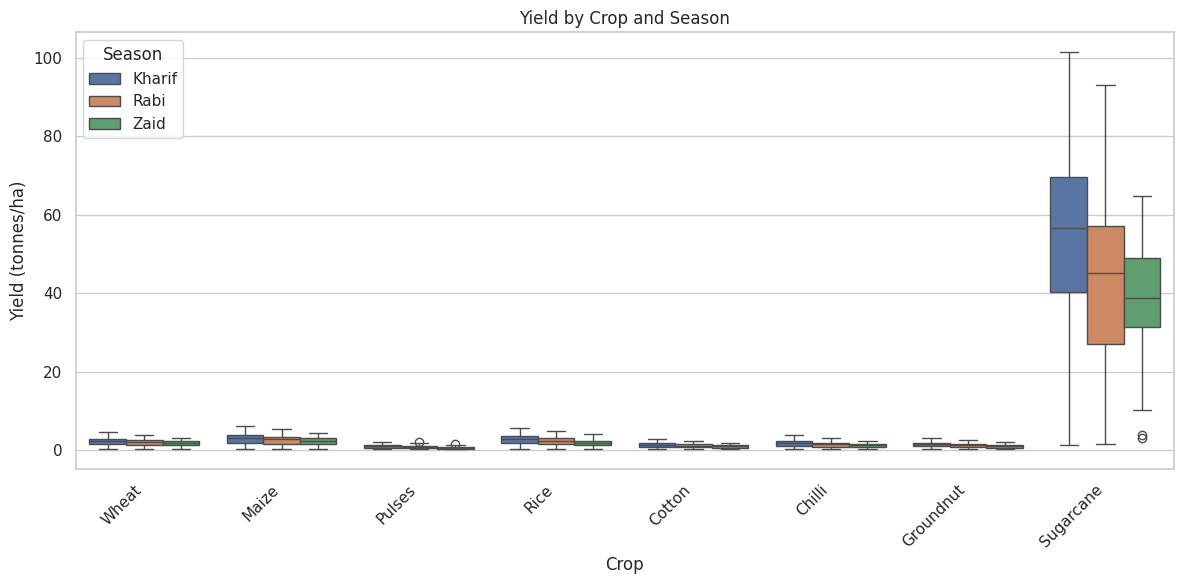

In [38]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season")
plt.xticks(rotation=45, ha="right")
plt.title("Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

In [39]:
crop_season_summary = (
    df.groupby(["Season", "Crop"])
      .agg(
          Average_Yield=("Yield_Tonnes_Ha", "mean"),
          Average_Profit=("Profit_INR", "mean"),
          Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
      )
      .round(2)
      .sort_values(["Season", "Average_Yield"], ascending=[True, False])
)

crop_season_summary

Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46    1,000,790.81                     36.00
       Maize               2.97      -39,332.67                      6.05
       Rice                2.70      -64,903.40                      2.17
       Wheat               2.25     -105,871.87                      4.76
       Chilli              1.73      954,380.42                      3.26
       Groundnut           1.48      108,265.44                      3.58
       Cotton              1.37      216,999.55                      2.13
       Pulses              1.04       43,338.90                      3.35
Rabi   Sugarcane          43.29      731,612.86                     27.92
       Maize               2.60      -89,133.40                      5.46
       Rice                2.32      -98,427.87                      1.84
       Wheat               2.06     -119,954.57                      4.69
       Chilli              1.47      638,572.50                      2.89
       Groundnut           1.23       10,416.54                      2.90
       Cotton              1.20      107,343.59                      1.94
       Pulses              0.88      -14,309.14                      2.70
Zaid   Sugarcane          38.42      583,635.80                     23.39
       Maize               2.29     -194,049.17                      4.75
       Rice                1.90     -227,239.34                      1.53
       Wheat               1.75     -193,208.95                      4.02
       Chilli              1.20      448,659.09                      2.20
       Groundnut           1.04      -68,872.50                      2.47
       Cotton              0.96      -53,925.34                      1.49
       Pulses              0.67     -139,227.81                      1.95

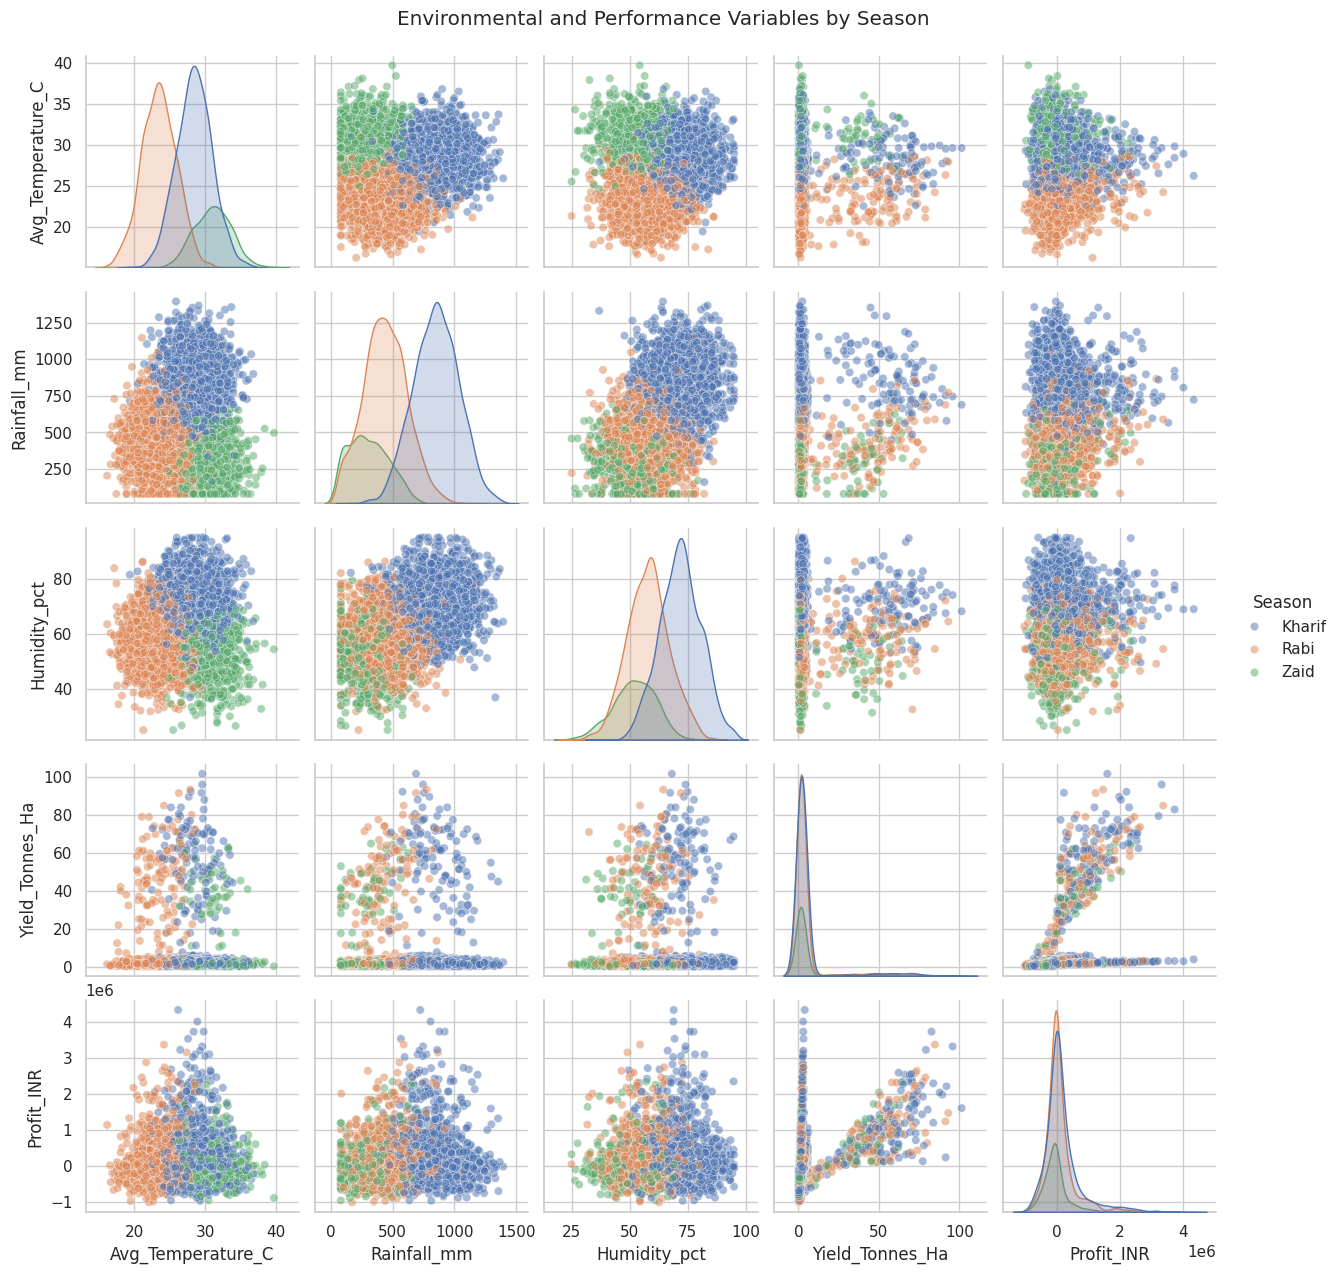

In [40]:
selected_columns = [
    "Avg_Temperature_C",
    "Rainfall_mm",
    "Humidity_pct",
    "Yield_Tonnes_Ha",
    "Profit_INR",
    "Season"
]

sns.pairplot(
    df[selected_columns],
    hue="Season",
    plot_kws={"alpha": 0.5}
)

plt.suptitle(
    "Environmental and Performance Variables by Season",
    y=1.02
)
plt.show()

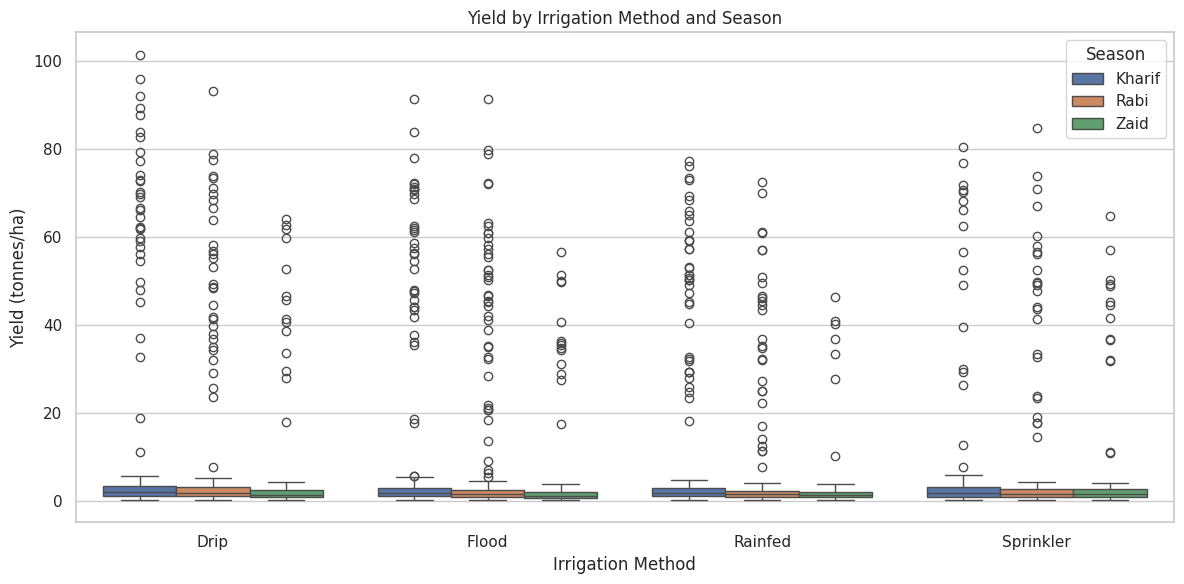

In [41]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha",
    hue="Season"
)
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

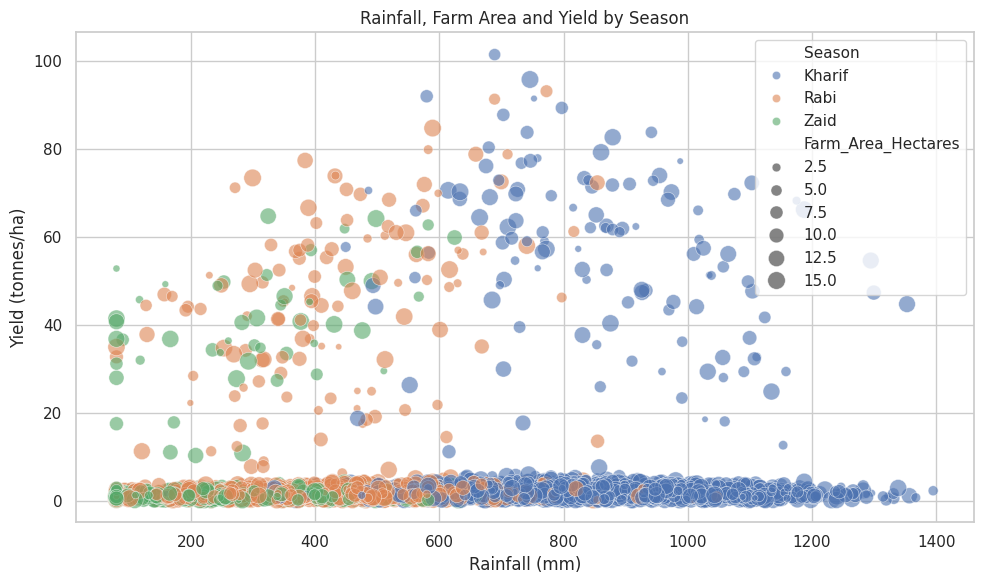

In [42]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 160),
    alpha=0.6
)
plt.title("Rainfall, Farm Area and Yield by Season")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

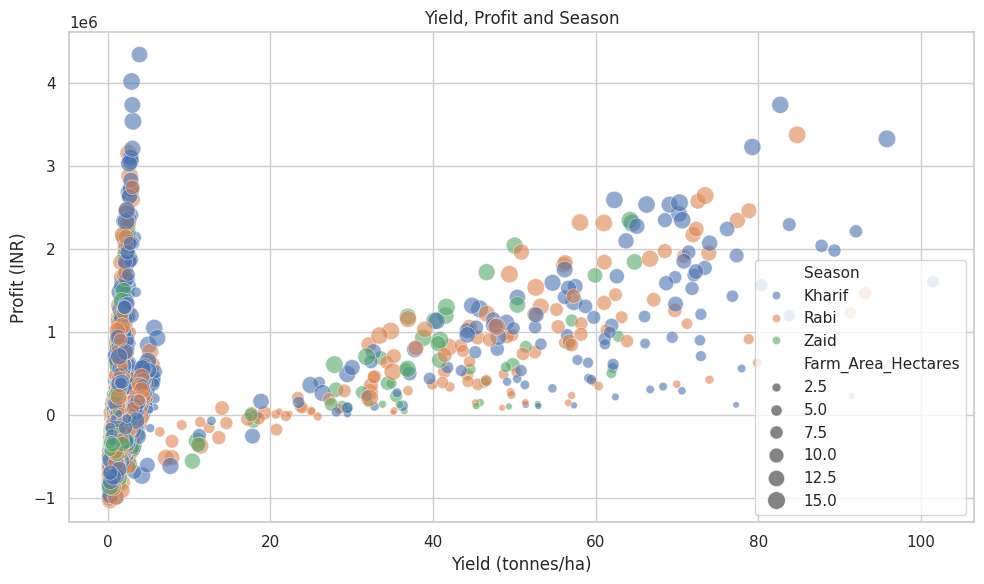

In [43]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 160),
    alpha=0.6
)
plt.title("Yield, Profit and Season")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

## 13. Correlation Analysis

I used correlation to check which numerical variables move together. Correlation does not mean that one variable causes another.

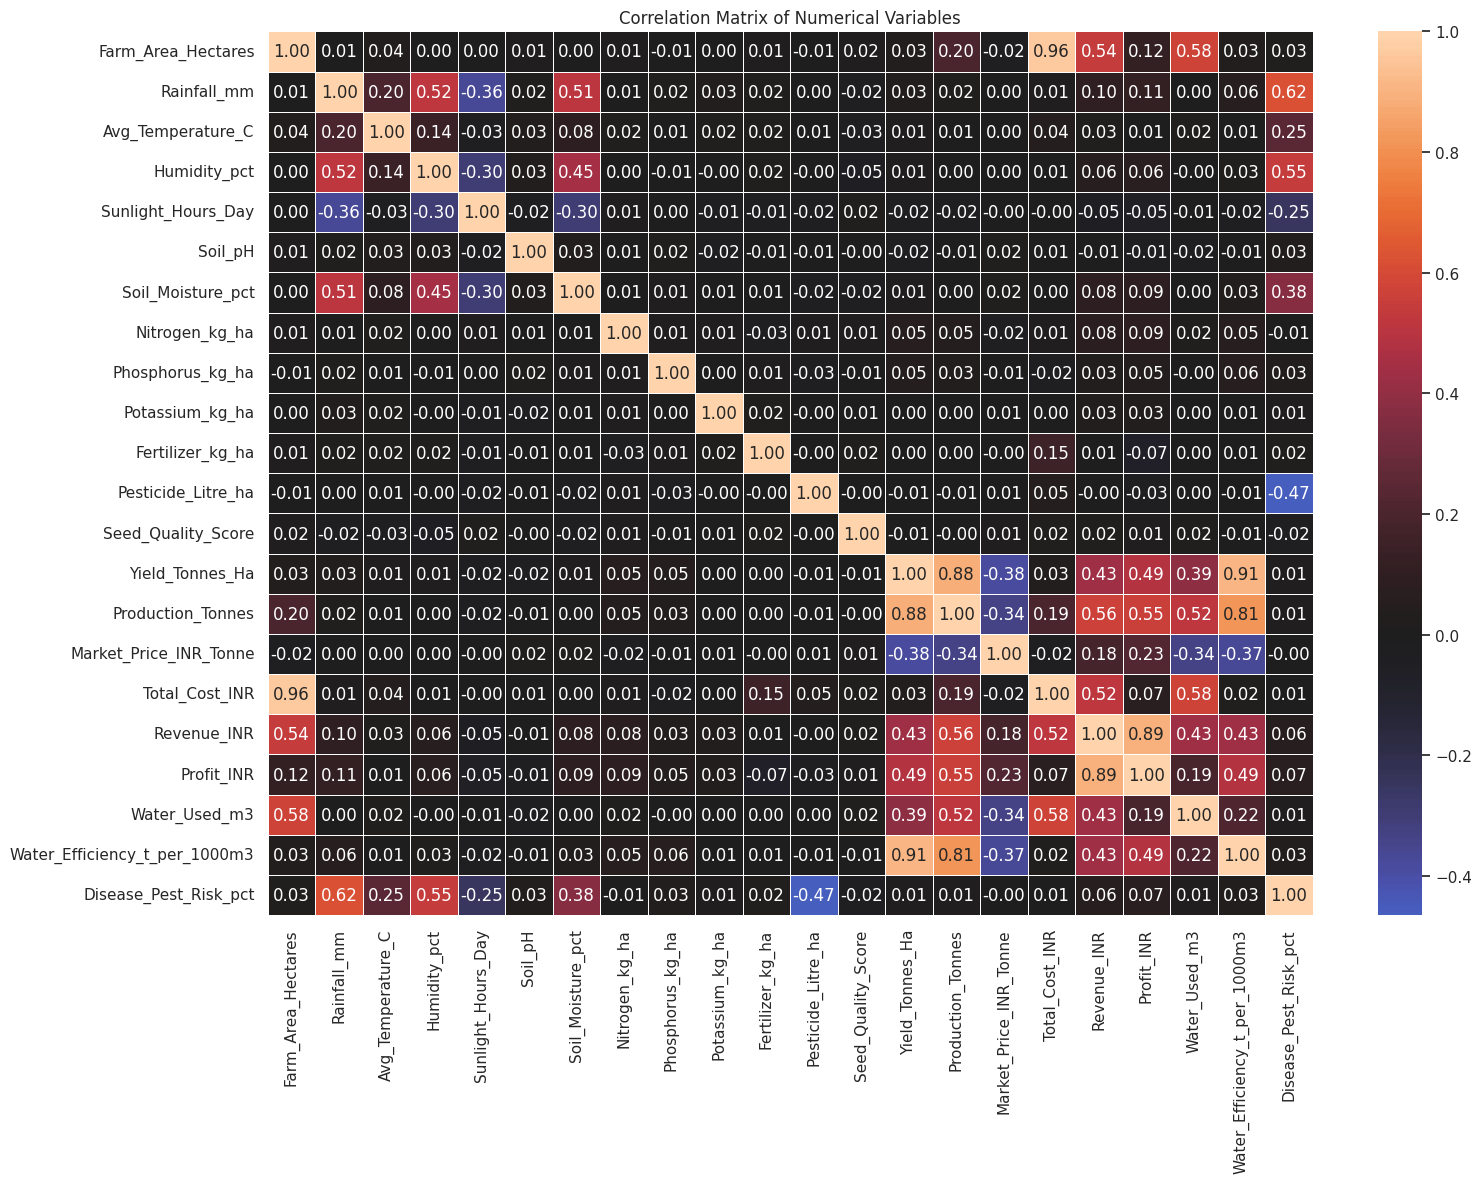

In [44]:
corr = df[numeric_columns].corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

In [45]:
# Top correlations with yield and profit
yield_corr = corr["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha").abs().sort_values(ascending=False)
profit_corr = corr["Profit_INR"].drop("Profit_INR").abs().sort_values(ascending=False)

print("Variables most strongly associated with Yield (absolute correlation):")
display(yield_corr.head(8).to_frame("Absolute_Correlation"))

print("\nVariables most strongly associated with Profit (absolute correlation):")
display(profit_corr.head(8).to_frame("Absolute_Correlation"))

Variables most strongly associated with Yield (absolute correlation):


,Absolute_Correlation
Water_Efficiency_t_per_1000m3,0.91
Production_Tonnes,0.88
Profit_INR,0.49
Revenue_INR,0.43
Water_Used_m3,0.39
Market_Price_INR_Tonne,0.38
Nitrogen_kg_ha,0.05
Phosphorus_kg_ha,0.05



Variables most strongly associated with Profit (absolute correlation):


,Absolute_Correlation
Revenue_INR,0.89
Production_Tonnes,0.55
Water_Efficiency_t_per_1000m3,0.49
Yield_Tonnes_Ha,0.49
Market_Price_INR_Tonne,0.23
Water_Used_m3,0.19
Farm_Area_Hectares,0.12
Rainfall_mm,0.11


## 14. Seasonal Comparison

This section combines the main performance measures so that the seasons can be compared more easily.

In [46]:
season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).round(2)

season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used,Average_Water_Efficiency
Season,,,,,,,
Kharif,1779,5.63,"82,387.61","178,914.65",318289158,"6,102.20",5.89
Rabi,1627,5.04,"67,498.88","87,689.47",142670768,"5,846.99",5.19
Zaid,594,4.64,"23,098.35","-24,804.82",-14734066,"6,419.89",4.41


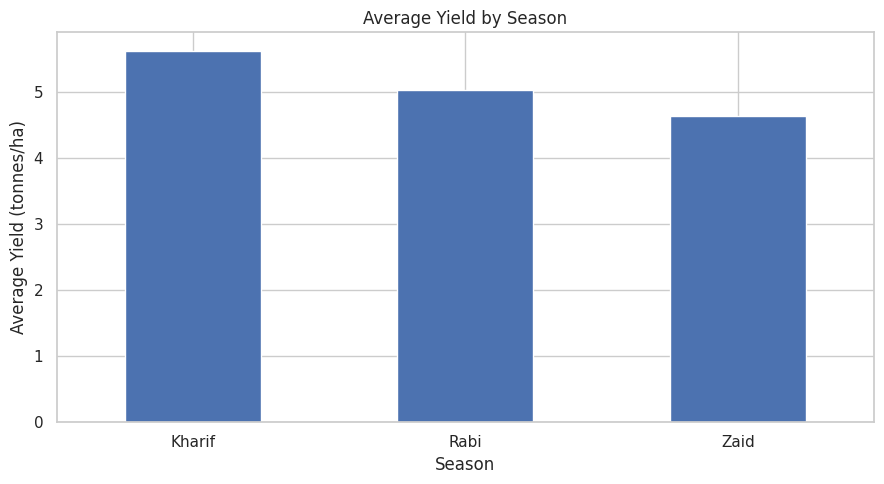

In [47]:
plt.figure(figsize=(9, 5))
season_metrics["Average_Yield"].sort_values(ascending=False).plot(kind="bar")
plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (tonnes/ha)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

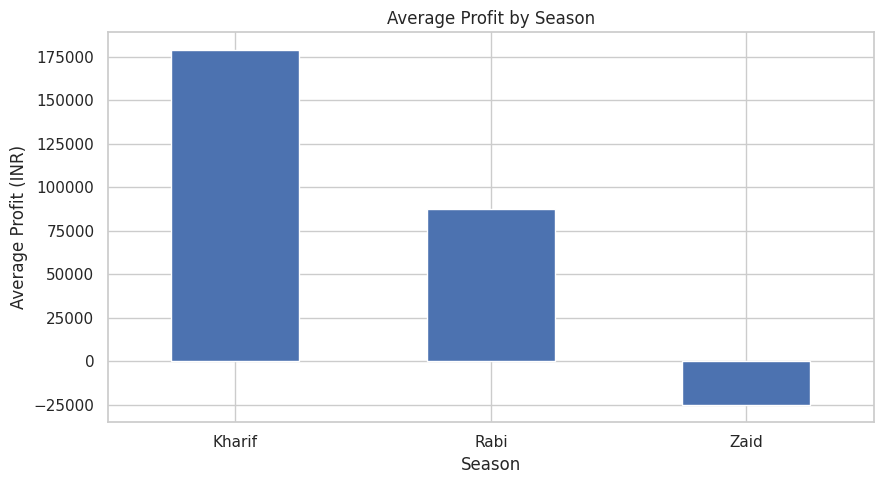

In [48]:
plt.figure(figsize=(9, 5))
season_metrics["Average_Profit"].sort_values(ascending=False).plot(kind="bar")
plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 15. My Additional Analysis 1 - Which crops are more profitable?

**Question:** Which crops have the highest average profit and profit margin?

I added profit margin because a high total profit does not always mean that the crop is efficient relative to its revenue.

In [49]:
df["Profit_Margin_pct"] = np.where(
    df["Revenue_INR"] != 0,
    (df["Profit_INR"] / df["Revenue_INR"]) * 100,
    np.nan
)

crop_profit = df.groupby("Crop").agg(
    Average_Profit=("Profit_INR", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Profit_Margin=("Profit_Margin_pct", "mean"),
    Records=("Farm_ID", "count")
).sort_values("Average_Profit", ascending=False)

crop_profit.round(2)

,Average_Profit,Average_Revenue,Average_Profit_Margin,Records
Crop,,,,
Sugarcane,"817,187.99","1,371,980.11",27.35,305
Chilli,"750,878.34","1,276,777.23",33.78,412
Cotton,"124,546.92","639,423.08",-8.23,508
Groundnut,"44,858.12","542,935.50",-28.66,424
Pulses,"-4,238.05","528,465.87",-36.48,496
Maize,"-83,978.33","457,067.99",-81.54,551
Rice,"-102,213.50","423,615.26",-99.37,690
Wheat,"-123,398.34","400,104.89",-91.70,614


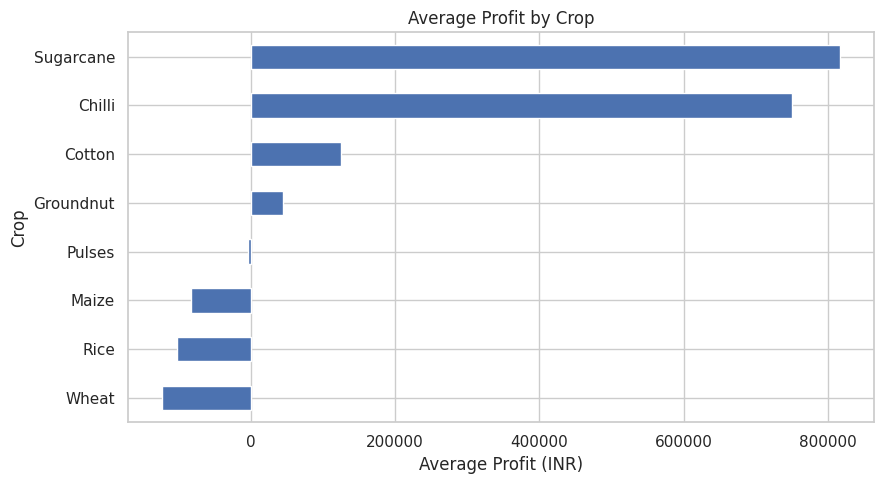

In [50]:
top_crops = crop_profit.head(8).sort_values("Average_Profit")

plt.figure(figsize=(9, 5))
top_crops["Average_Profit"].plot(kind="barh")
plt.title("Average Profit by Crop")
plt.xlabel("Average Profit (INR)")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

## 16. My Additional Analysis 2 - Which irrigation method looks more efficient?

**Question:** How do irrigation methods compare in yield, water usage and water efficiency?

In [51]:
irrigation_summary = df.groupby("Irrigation_Method").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Average_Profit=("Profit_INR", "mean")
).sort_values("Average_Water_Efficiency", ascending=False)

irrigation_summary.round(2)

,Records,Average_Yield,Average_Water_Used,Average_Water_Efficiency,Average_Profit
Irrigation_Method,,,,,
Rainfed,1041,4.60,"3,549.55",7.56,"79,050.37"
Drip,915,6.58,"5,918.75",6.27,"219,626.00"
Sprinkler,734,5.16,"6,208.26",4.67,"91,121.08"
Flood,1310,4.86,"8,026.47",3.44,"73,354.02"


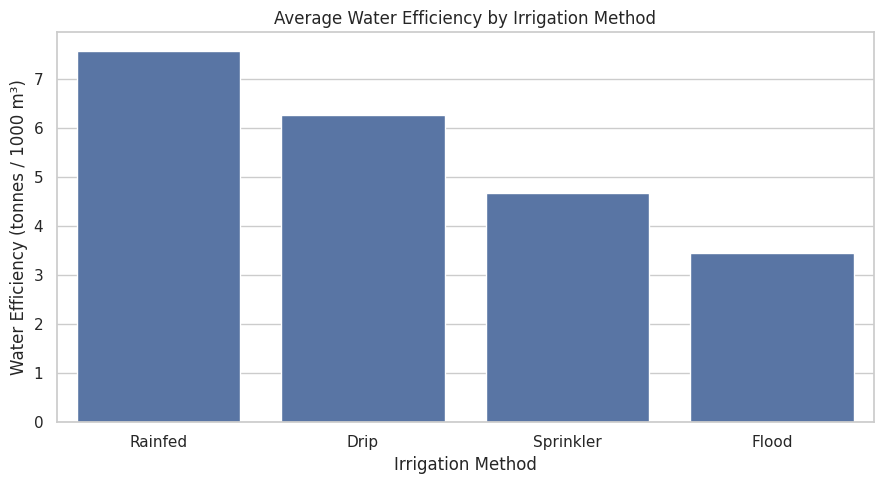

In [52]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=irrigation_summary.reset_index(),
    x="Irrigation_Method",
    y="Average_Water_Efficiency",
    errorbar=None
)
plt.title("Average Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency (tonnes / 1000 m³)")
plt.tight_layout()
plt.show()

## 17. My Additional Analysis 3 - Does higher disease/pest risk relate to lower performance?

**Question:** Does the average profit or yield change when disease/pest risk is low, medium or high?

I created simple risk groups so the comparison is easier to understand.

In [53]:
df["Risk_Group"] = pd.cut(
    df["Disease_Pest_Risk_pct"],
    bins=[0, 33.33, 66.67, 100],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

risk_summary = df.groupby("Risk_Group", observed=False).agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2)

risk_summary

,Records,Average_Yield,Average_Profit,Average_Water_Used
Risk_Group,,,,
Low Risk,616,4.87,"14,227.49","6,115.05"
Medium Risk,3171,5.34,"133,360.70","6,023.21"
High Risk,213,4.83,"68,426.91","6,177.48"


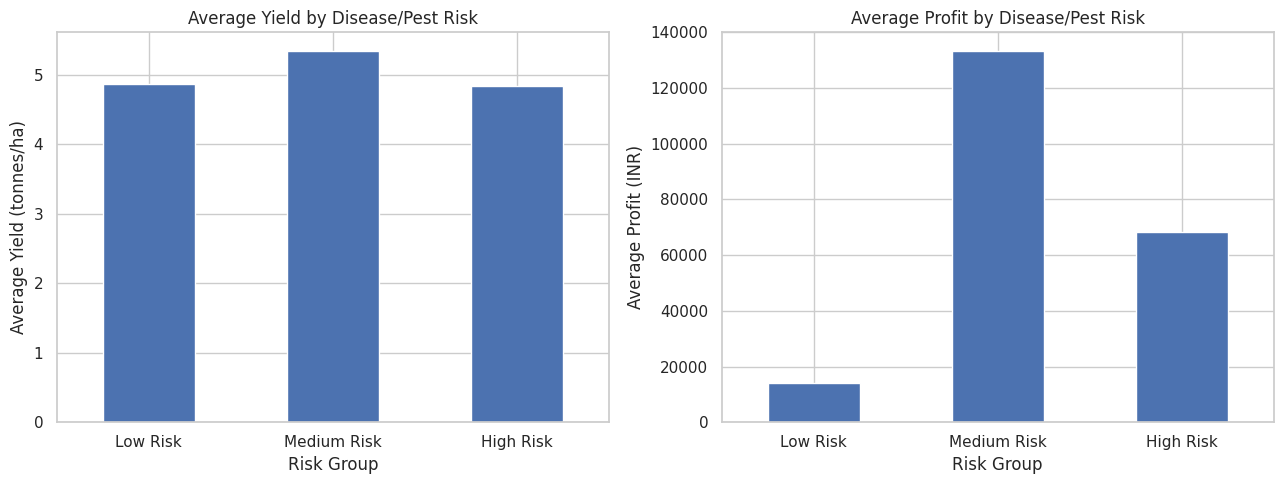

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

risk_summary["Average_Yield"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Yield by Disease/Pest Risk")
axes[0].set_xlabel("Risk Group")
axes[0].set_ylabel("Average Yield (tonnes/ha)")
axes[0].tick_params(axis="x", rotation=0)

risk_summary["Average_Profit"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Profit by Disease/Pest Risk")
axes[1].set_xlabel("Risk Group")
axes[1].set_ylabel("Average Profit (INR)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 18. Key Insights

The following points are generated from the calculated results so that the observations are directly connected to the dataset.

In [55]:
# Generate 8 evidence-based insights from the analysis

best_yield_season = season_metrics["Average_Yield"].idxmax()
worst_yield_season = season_metrics["Average_Yield"].idxmin()
best_profit_season = season_metrics["Average_Profit"].idxmax()
worst_profit_season = season_metrics["Average_Profit"].idxmin()

best_crop_yield = df.groupby("Crop")["Yield_Tonnes_Ha"].mean().idxmax()
best_crop_yield_value = df.groupby("Crop")["Yield_Tonnes_Ha"].mean().max()

best_crop_profit = crop_profit["Average_Profit"].idxmax()
best_crop_profit_value = crop_profit["Average_Profit"].max()

best_irrigation = irrigation_summary["Average_Water_Efficiency"].idxmax()
best_irrigation_eff = irrigation_summary["Average_Water_Efficiency"].max()

yield_profit_corr = df[["Yield_Tonnes_Ha", "Profit_INR"]].corr().iloc[0, 1]

highest_water_season = season_metrics["Average_Water_Used"].idxmax()
lowest_water_season = season_metrics["Average_Water_Used"].idxmin()

risk_yield_diff = None
if risk_summary["Average_Yield"].notna().sum() >= 2:
    risk_yield_diff = (
        risk_summary["Average_Yield"].max()
        - risk_summary["Average_Yield"].min()
    )

insights = [
    f"1. **Seasonal yield:** {best_yield_season} has the highest average yield ({season_metrics.loc[best_yield_season, 'Average_Yield']:.2f} tonnes/ha), while {worst_yield_season} has the lowest ({season_metrics.loc[worst_yield_season, 'Average_Yield']:.2f} tonnes/ha).",
    f"2. **Seasonal profit:** {best_profit_season} has the highest average profit ({season_metrics.loc[best_profit_season, 'Average_Profit']:,.0f} INR per record), while {worst_profit_season} has the lowest ({season_metrics.loc[worst_profit_season, 'Average_Profit']:,.0f} INR).",
    f"3. **Best crop for yield:** {best_crop_yield} has the highest average yield across the crops at about {best_crop_yield_value:.2f} tonnes/ha.",
    f"4. **Best crop for average profit:** {best_crop_profit} has the highest average profit at about {best_crop_profit_value:,.0f} INR.",
    f"5. **Water use:** {highest_water_season} has the highest average water usage ({season_metrics.loc[highest_water_season, 'Average_Water_Used']:,.0f} m³), while {lowest_water_season} has the lowest ({season_metrics.loc[lowest_water_season, 'Average_Water_Used']:,.0f} m³).",
    f"6. **Irrigation efficiency:** {best_irrigation} has the highest average water-efficiency value ({best_irrigation_eff:.2f} tonnes per 1000 m³) among the irrigation methods in the dataset.",
    f"7. **Yield and profit:** The correlation between yield and profit is {yield_profit_corr:.2f}. This shows the strength and direction of their linear association in this dataset, but it should not be treated as proof of causation.",
    f"8. **Disease/pest risk:** The difference between the highest and lowest risk-group average yields is about {risk_yield_diff:.2f} tonnes/ha, so disease/pest risk is worth considering as one of the factors for further investigation."
]

display(Markdown("\n\n".join(insights)))

1. **Seasonal yield:** Kharif has the highest average yield (5.63 tonnes/ha), while Zaid has the lowest (4.64 tonnes/ha).

2. **Seasonal profit:** Kharif has the highest average profit (178,915 INR per record), while Zaid has the lowest (-24,805 INR).

3. **Best crop for yield:** Sugarcane has the highest average yield across the crops at about 46.64 tonnes/ha.

4. **Best crop for average profit:** Sugarcane has the highest average profit at about 817,188 INR.

5. **Water use:** Zaid has the highest average water usage (6,420 m³), while Rabi has the lowest (5,847 m³).

6. **Irrigation efficiency:** Rainfed has the highest average water-efficiency value (7.56 tonnes per 1000 m³) among the irrigation methods in the dataset.

7. **Yield and profit:** The correlation between yield and profit is 0.49. This shows the strength and direction of their linear association in this dataset, but it should not be treated as proof of causation.

8. **Disease/pest risk:** The difference between the highest and lowest risk-group average yields is about 0.51 tonnes/ha, so disease/pest risk is worth considering as one of the factors for further investigation.

## 19. Evidence-Based Recommendations

Based on the analysis, my recommendations are:

- Seasonal planning should consider the differences in average yield and profit between Kharif, Rabi and Zaid.
- Crops with consistently better profit should be studied further before choosing them for expansion because profit can also depend on cost, market price and farm size.
- Water-efficiency results can be used to identify irrigation methods that deserve more attention.
- High water-use groups should be reviewed to see whether similar production can be achieved with better water efficiency.
- Disease and pest risk should be monitored because the risk-group comparison shows differences in performance.
- Extreme values should not be removed without checking whether they are genuine agricultural observations.
- Before making real farming decisions, the results should be validated with more years of data and reliable field information.

## 20. Limitations

There are some limitations in this analysis:

1. The analysis is based on the available dataset only.
2. Missing numerical values were filled using median imputation.
3. IQR was used to identify possible outliers, but outliers were not automatically removed.
4. Correlation shows association, not causation.
5. The dataset may not represent every agricultural region or every real-world farming condition.
6. More historical data would be useful for studying long-term seasonal trends.
7. The analysis does not include external factors such as detailed market fluctuations, government policies or individual farmer decisions.

## 21. Conclusion

In [56]:
print("Conclusion")
print("----------")
print(
    f"The analysis shows that agricultural performance differs across seasons. "
    f"{best_yield_season} has the highest average yield, while {best_profit_season} "
    f"has the highest average profit in this dataset."
)
print(
    f"The crop-level analysis shows that {best_crop_yield} has the highest average yield, "
    f"while {best_crop_profit} has the highest average profit."
)
print(
    f"The irrigation analysis identifies {best_irrigation} as having the highest "
    f"average water-efficiency value among the available methods."
)
print(
    "Overall, the project helped me understand how data cleaning, descriptive statistics, "
    "visualization, correlation and group comparisons can be used to study agricultural performance."
)
print(
    "These findings can support further investigation, but they should not be treated as "
    "direct causal or field-level recommendations without additional data."
)

Conclusion
----------
The analysis shows that agricultural performance differs across seasons. Kharif has the highest average yield, while Kharif has the highest average profit in this dataset.
The crop-level analysis shows that Sugarcane has the highest average yield, while Sugarcane has the highest average profit.
The irrigation analysis identifies Rainfed as having the highest average water-efficiency value among the available methods.
Overall, the project helped me understand how data cleaning, descriptive statistics, visualization, correlation and group comparisons can be used to study agricultural performance.
These findings can support further investigation, but they should not be treated as direct causal or field-level recommendations without additional data.


## 22. Final Project Checklist

- [x] Dataset loaded successfully
- [x] Top 5 rows analyzed
- [x] Dataset shape and structure examined
- [x] Data types examined
- [x] Missing values identified and handled
- [x] Duplicate records identified and handled
- [x] Descriptive/statistical analysis performed
- [x] Outliers investigated
- [x] Univariate analysis completed
- [x] Bivariate analysis completed
- [x] Multivariate analysis completed
- [x] Correlation analysis completed
- [x] Seasonal comparisons performed
- [x] 3 student-designed analyses completed
- [x] At least 8 meaningful insights documented
- [x] Evidence-based recommendations provided
- [x] Limitations discussed
- [x] Final conclusion provided


